In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray

In [14]:
with rasterio.open("Sentinel/sentinel2-nir_2021_590108_7225793_649409_7317568.tif") as src:
    nir_2021 = src.read(1).astype("float32")

with rasterio.open("Sentinel/sentinel2-swir_2021_590108_7225793_649409_7317568.tif") as src:
    swir_2021 = src.read(1).astype("float32")

with rasterio.open("Sentinel/sentinel2-swir_2021_590108_7225793_649409_7317568.tif") as src:
    nir_2023 = src.read(1).astype("float32")

with rasterio.open("Sentinel/sentinel2-swir_2023_590108_7225793_649409_7317568.tif") as src:
    swir_2023 = src.read(1).astype("float32")

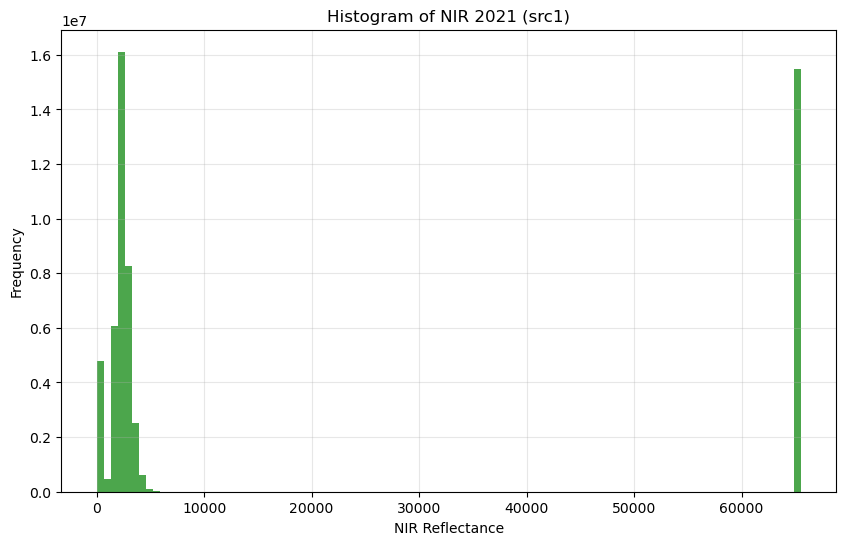

In [12]:
# Flatten array and remove NaNs
nir_2021_flat = nir_2021.flatten()
nir_2021_flat = nir_2021_flat[~np.isnan(nir_2021_flat)]

plt.figure(figsize=(10,6))
plt.hist(nir_2021_flat, bins=100, color='green', alpha=0.7)
plt.title("Histogram of NIR 2021 (src1)")
plt.xlabel("NIR Reflectance")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Calculate NIR difference
nir_diff = nir_2023 - nir_2021

# Optional: highlight significant changes
threshold = 0.1  # adjust depending on reflectance scale
change_mask = np.abs(nir_diff) > threshold

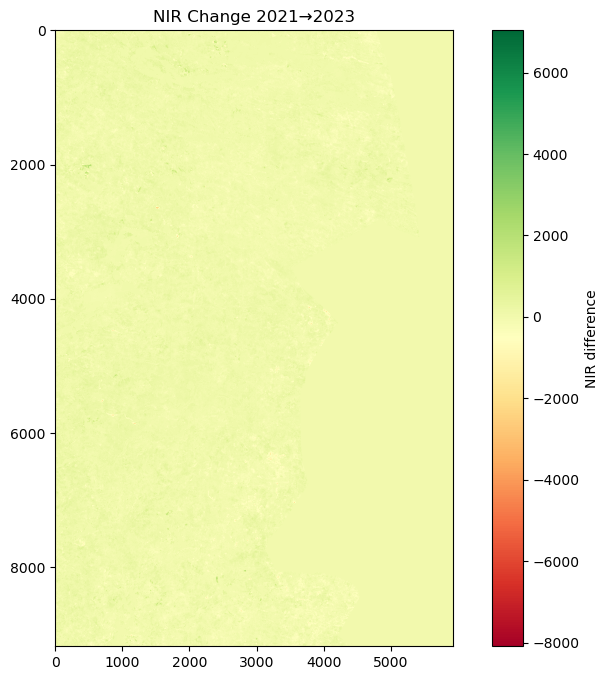

In [6]:
plt.figure(figsize=(10,8))
plt.imshow(nir_diff, cmap="RdYlGn")  # red=decrease, green=increase
plt.colorbar(label="NIR difference")
plt.title("NIR Change 2021→2023")
plt.show()

In [8]:
# Save nir_diff using NIR_2021.tif as reference
with rasterio.open("Sentinel/sentinel2-nir_2021_590108_7225793_649409_7317568.tif") as ref:
    out_meta = ref.meta.copy()
    out_meta.update({
        "dtype": "float32",  # keep difference values
        "count": 1
    })

with rasterio.open("Sentinel/sentinel_nir_changes_2021_2023.tif", "w", **out_meta) as dst:
    dst.write(nir_diff.astype("float32"), 1)

print("nir_changes_2021_2023.tif saved!")

nir_changes_2021_2023.tif saved!


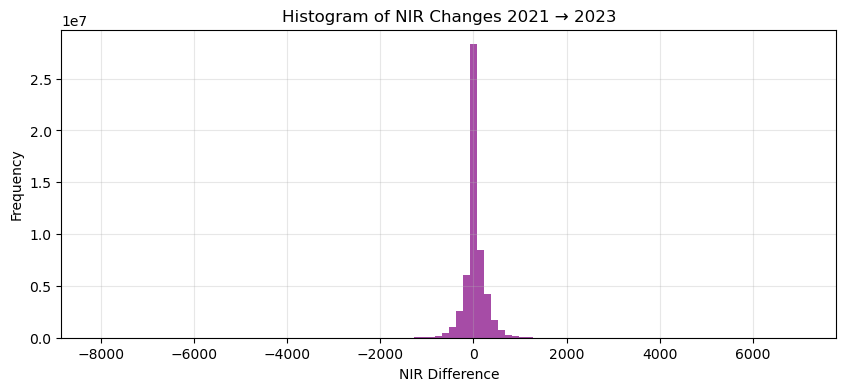

In [11]:
# Flatten array and remove NaNs
nir_diff_flat = nir_diff.flatten()
nir_diff_flat = nir_diff_flat[~np.isnan(nir_diff_flat)]

plt.figure(figsize=(10,4))
plt.hist(nir_diff_flat, bins=100, color='purple', alpha=0.7)
plt.title("Histogram of NIR Changes 2021 → 2023")
plt.xlabel("NIR Difference")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# Water Index

In [15]:
# Calculate MNDWI for both years
mndwi_2021 = (nir_2021 - swir_2021) / (nir_2021 + swir_2021 + 1e-6)
mndwi_2023 = (nir_2023 - swir_2023) / (nir_2023 + swir_2023 + 1e-6)

In [16]:
# 3️Calculate difference (water change)
water_diff = mndwi_2023 - mndwi_2021

In [17]:
threshold = 0.1  # adjust depending on reflectance scale
water_change_mask = np.abs(water_diff) > threshold

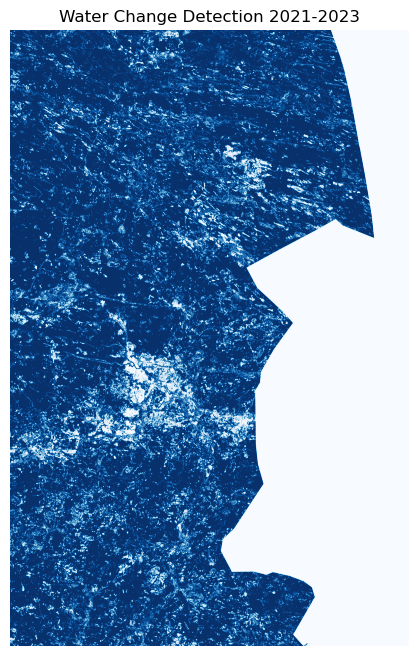

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(water_change_mask, cmap="Blues")
plt.title("Water Change Detection 2021-2023")
plt.axis("off")
plt.show()


In [22]:
 # Save the actual difference values
with rasterio.open(
    "Sentinel/water_changes_2021_2023.tif",
    "w",
    driver="GTiff",
    height=water_diff.shape[0],
    width=water_diff.shape[1],
    count=1,
    dtype="float32",       # float32 to preserve negative/decimal values
    crs=src.crs,
    transform=src.transform
) as dst:
    dst.write(water_diff.astype("float32"), 1)

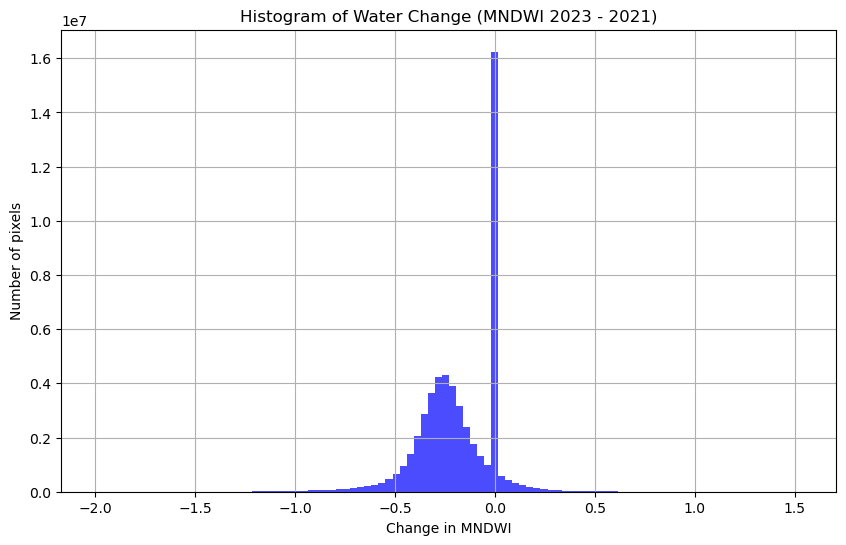

In [21]:
plt.figure(figsize=(10,6))
plt.hist(water_diff.flatten(), bins=100, color="blue", alpha=0.7)
plt.title("Histogram of Water Change (MNDWI 2023 - 2021)")
plt.xlabel("Change in MNDWI")
plt.ylabel("Number of pixels")
plt.grid(True)
plt.show()